In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the CSV file
path = r"data_with_needed_columns.csv"
df = pd.read_csv(path, parse_dates=['Timestamp'])
# df["Timestamp"] = pd.to_datetime(df["Timestamp"],dayfirst='True')

In [3]:
df_columns_to_keep = ['Timestamp', 'TPCODL Demand', 'TPWODL Demand', 'TPNODL Demand',
       'TPSOSDL Demand', 'Total Demand (as recorded)']

df.drop(columns=[col for col in df.columns if col not in df_columns_to_keep], inplace=True)

# df.to_csv("data_with_needed_columns.csv", date_format='%Y-%m-%d %H:%M:%S', index=False)

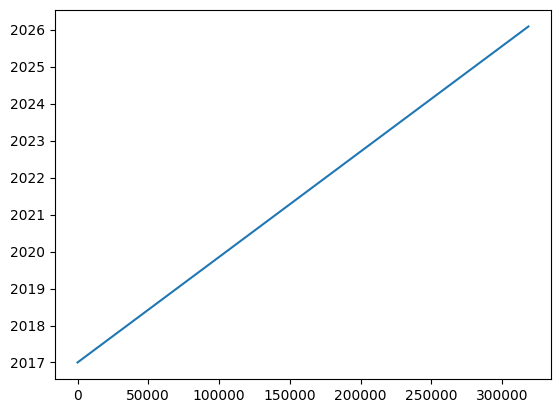

In [4]:
# Define the cutoff timestamp
cutoff_timestamp = pd.Timestamp("2026-06-08 00:00:00")  # Change as needed

# Keep only rows where Timestamp is on or after the cutoff
df_filtered = df[df["Timestamp"] < cutoff_timestamp]

# # Save the filtered DataFrame
# df_filtered.to_csv("2025_latest_data_filtered.csv", index=False)

# print("Data above", cutoff_timestamp, "removed and saved as '2025_latest_data_filtered.csv'.")

plt.plot(df_filtered["Timestamp"])
plt.show()

In [5]:
print(df.max())
print(df.min())

Timestamp                     2026-01-31 23:45:00
TPCODL Demand                         2480.270671
TPWODL Demand                         3882.599613
TPNODL Demand                         1625.364591
TPSOSDL Demand                         762.644177
Total Demand (as recorded)            7158.521712
dtype: object
Timestamp                     2017-01-01 00:00:00
TPCODL Demand                          227.104673
TPWODL Demand                           248.16108
TPNODL Demand                          243.011213
TPSOSDL Demand                         150.746828
Total Demand (as recorded)            1324.931193
dtype: object


In [6]:
# Check for missing values in each column
missing_values = df.isna().sum()

# Display only columns that have missing values
missing_values = missing_values[missing_values > 0]

# Print missing value count for each affected column
print("Missing Values in Merged Dataset:")
print(missing_values)

# Optional: Show rows with missing values
missing_rows = df[df.isna().any(axis=1)]
print("\nRows with Missing Values:")
print(missing_rows.head())  # Show first few rows with missing values


Missing Values in Merged Dataset:
Series([], dtype: int64)

Rows with Missing Values:
Empty DataFrame
Columns: [Timestamp, TPCODL Demand, TPWODL Demand, TPNODL Demand, TPSOSDL Demand, Total Demand (as recorded)]
Index: []


In [7]:
# # Fill missing values using the value from exactly 7 days (1 week) ago
df = df.sort_values("Timestamp")  # Ensure sorted order
df = df.set_index("Timestamp")  # Set timestamp as index for shifting

# # Apply shifting for all columns (excluding the timestamp)
df = df.fillna(df.shift(7 * 96))  # 7 days * 96 (15-min intervals per day)

# # Reset index after filling
df = df.reset_index()

# # Save the cleaned dataset
# df.to_csv("cleaned_demand_data.csv", index=False)

# Display summary of remaining missing values (if any)
missing_values_after = df.isna().sum()
print("Missing values after filling with previous week data:")
print(missing_values_after)


Missing values after filling with previous week data:
Timestamp                     0
TPCODL Demand                 0
TPWODL Demand                 0
TPNODL Demand                 0
TPSOSDL Demand                0
Total Demand (as recorded)    0
dtype: int64


In [ ]:
def handle_out_of_range_and_fill(df):
    """ Handle out-of-range values by replacing them with NaN and filling with day-back values """

    for column in df.columns:
        if df[column].dtype == float:
            # Replace negative values and values greater than 10,000 with NaN
            df[column] = df[column].apply(lambda x: np.nan if x < 0 or x > 10000 else x)

            # Fill NaN values with day-back value (96 intervals back for 15-minute data)
            df[column] = df[column].fillna(method='ffill', limit=96)

            # Check minimum and maximum values after handling
            min_value = df[column].min()
            max_value = df[column].max()

            print(f"Column: {column}")
            print(f"  Minimum Value: {min_value}")
            print(f"  Maximum Value: {max_value}\n")

    return df

cleaned_df = handle_out_of_range_and_fill(df)

# def convert_to_float_and_clean(df, column_name):
#     # Convert column to float where possible, set to NaN otherwise
#     df[column_name] = pd.to_numeric(df[column_name], errors='coerce')

#     return df

# # Columns to clean and convert
# columns_to_clean = ['Renewables Generation (SOLAR)', 'Frequency', 'NALCO Drawl', 'IMFA Drawl', 'Vedanta Drawl']

# for column in columns_to_clean:
#     cleaned_df = convert_to_float_and_clean(cleaned_df, column)

# # Display the cleaned DataFrame
# print(cleaned_df)

In [8]:
# Outlier detection helpers: IQR, Z-score, and Moving-Average multiplier

def iqr_outlier_mask(series, k=1.5):
    s = pd.to_numeric(series, errors='coerce')
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    if pd.isna(iqr) or iqr == 0:
        return pd.Series(False, index=s.index)
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return (s < lower) | (s > upper)


def zscore_outlier_mask(series, threshold=3.0):
    s = pd.to_numeric(series, errors='coerce')
    std = s.std(ddof=0)
    if pd.isna(std) or std == 0:
        return pd.Series(False, index=s.index)
    z = (s - s.mean()) / std
    return z.abs() > threshold


def moving_average_multiplier_outlier_mask(series, window=96, multiplier=1.5, min_periods=None):
    """
    Flags points outside MA-based bounds.
    For multiplier=1.5, allowed band is MA +/- 50% of |MA|.
    """
    if multiplier <= 1:
        raise ValueError("multiplier must be > 1")

    s = pd.to_numeric(series, errors='coerce')
    if min_periods is None:
        min_periods = max(3, window // 4)

    ma = s.rolling(window=window, min_periods=min_periods).mean()
    band = (multiplier - 1) * ma.abs()
    lower = ma - band
    upper = ma + band

    mask = ((s < lower) | (s > upper)) & ma.notna()
    return mask.fillna(False)


def detect_outliers(
    df,
    columns,
    methods=("moving_average",),
    iqr_k=1.5,
    z_threshold=3.0,
    ma_window=96,
    ma_multiplier=1.5,
    ma_min_periods=None,
    combine="any",
):
    methods = tuple(methods)
    outlier_masks = {}

    for col in columns:
        series = pd.to_numeric(df[col], errors='coerce')
        method_masks = []

        if "iqr" in methods:
            method_masks.append(iqr_outlier_mask(series, k=iqr_k))

        if "zscore" in methods:
            method_masks.append(zscore_outlier_mask(series, threshold=z_threshold))

        if "moving_average" in methods:
            method_masks.append(
                moving_average_multiplier_outlier_mask(
                    series,
                    window=ma_window,
                    multiplier=ma_multiplier,
                    min_periods=ma_min_periods,
                )
            )

        if not method_masks:
            outlier_masks[col] = pd.Series(False, index=df.index)
        elif combine == "all":
            combined = method_masks[0].copy()
            for m in method_masks[1:]:
                combined &= m
            outlier_masks[col] = combined
        else:  # combine == "any"
            combined = method_masks[0].copy()
            for m in method_masks[1:]:
                combined |= m
            outlier_masks[col] = combined

    return pd.DataFrame(outlier_masks, index=df.index)


def clean_outliers(
    df,
    columns,
    methods=("moving_average",),
    remove_outliers=True,
    fill_method="week_shift",
    week_periods=96 * 7,
    **detect_kwargs,
):
    cleaned = df.copy()
    mask_df = detect_outliers(cleaned, columns, methods=methods, **detect_kwargs)

    for col in columns:
        s = pd.to_numeric(cleaned[col], errors='coerce')

        if remove_outliers:
            s = s.mask(mask_df[col])

            if fill_method == "ffill":
                s = s.ffill()
            elif fill_method == "bfill":
                s = s.bfill()
            elif fill_method == "week_shift":
                s = s.fillna(s.shift(week_periods))
            elif fill_method in (None, "none"):
                pass
            else:
                raise ValueError("fill_method must be one of: 'ffill', 'bfill', 'week_shift', 'none'")

        cleaned[col] = s

    summary = pd.DataFrame({
        "outlier_count": mask_df.sum(),
        "outlier_pct": (mask_df.mean() * 100).round(3),
    })

    return cleaned, mask_df, summary


def detect_outliers_per_method(
    df,
    columns,
    methods=("moving_average",),
    iqr_k=1.5,
    z_threshold=3.0,
    ma_window=96,
    ma_multiplier=1.5,
    ma_min_periods=None,
):
    """Return one outlier mask DataFrame per method."""
    masks_by_method = {}

    for method in methods:
        masks_by_method[method] = detect_outliers(
            df,
            columns=columns,
            methods=(method,),
            iqr_k=iqr_k,
            z_threshold=z_threshold,
            ma_window=ma_window,
            ma_multiplier=ma_multiplier,
            ma_min_periods=ma_min_periods,
            combine="any",
        )

    return masks_by_method


def visualize_outliers_by_zone(
    df,
    masks_by_method,
    columns,
    timestamp_col="Timestamp",
    figsize_per_plot=(15, 4),
    method_colors=None,
    ma_window=96,
    ma_multiplier=1.5,
    ma_min_periods=None,
):
    """Plot each zone with MA envelope and method-wise outlier markers."""
    if method_colors is None:
        method_colors = {
            "iqr": "#d62728",
            "zscore": "#ff7f0e",
            "moving_average": "#2ca02c",
        }

    x = df[timestamp_col] if timestamp_col in df.columns else df.index

    for col in columns:
        fig, ax = plt.subplots(figsize=figsize_per_plot)
        y = pd.to_numeric(df[col], errors="coerce")

        ax.plot(x, y, color="steelblue", linewidth=0.8, alpha=0.8, label="Original")

        # Moving-average envelope (only when MA method is in use)
        if "moving_average" in masks_by_method:
            if ma_min_periods is None:
                ma_min_periods_local = max(3, ma_window // 4)
            else:
                ma_min_periods_local = ma_min_periods

            ma = y.rolling(window=ma_window, min_periods=ma_min_periods_local).mean()
            band = (ma_multiplier - 1) * ma.abs()
            lower = ma - band
            upper = ma + band

            ax.plot(x, ma, color="#1f7a1f", linewidth=1.0, alpha=0.9, label="MA")
            ax.plot(x, lower, color="#2ca02c", linewidth=0.8, linestyle="--", alpha=0.9, label="MA lower")
            ax.plot(x, upper, color="#2ca02c", linewidth=0.8, linestyle="--", alpha=0.9, label="MA upper")

        for method, mask_df in masks_by_method.items():
            mask = mask_df[col].fillna(False)
            count = int(mask.sum())
            if count > 0:
                ax.scatter(
                    x[mask],
                    y[mask],
                    s=16,
                    color=method_colors.get(method, "black"),
                    label=f"{method} ({count})",
                    zorder=3,
                )

        ax.set_title(f"{col}: Outliers by Method")
        ax.set_xlabel(timestamp_col if timestamp_col in df.columns else "Index")
        ax.set_ylabel(col)
        ax.legend(loc="upper right")
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()


def visualize_outliers_by_zone_plotly(
    df,
    masks_by_method,
    columns,
    timestamp_col="Timestamp",
    method_colors=None,
    ma_window=96,
    ma_multiplier=1.5,
    ma_min_periods=None,
):
    """Interactive Plotly chart per zone with MA envelope + method markers."""
    try:
        import plotly.graph_objects as go
    except ImportError:
        print("Plotly is not installed. Install with: pip install plotly")
        return

    if method_colors is None:
        method_colors = {
            "iqr": "#d62728",
            "zscore": "#ff7f0e",
            "moving_average": "#2ca02c",
        }

    x = df[timestamp_col] if timestamp_col in df.columns else df.index

    for col in columns:
        y = pd.to_numeric(df[col], errors="coerce")
        fig = go.Figure()

        fig.add_trace(
            go.Scatter(
                x=x,
                y=y,
                mode="lines",
                name="Original",
                line=dict(color="steelblue", width=1),
            )
        )

        # Moving-average envelope
        if "moving_average" in masks_by_method:
            if ma_min_periods is None:
                ma_min_periods_local = max(3, ma_window // 4)
            else:
                ma_min_periods_local = ma_min_periods

            ma = y.rolling(window=ma_window, min_periods=ma_min_periods_local).mean()
            band = (ma_multiplier - 1) * ma.abs()
            lower = ma - band
            upper = ma + band

            fig.add_trace(
                go.Scatter(
                    x=x,
                    y=ma,
                    mode="lines",
                    name="MA",
                    line=dict(color="#1f7a1f", width=1.5),
                )
            )
            fig.add_trace(
                go.Scatter(
                    x=x,
                    y=lower,
                    mode="lines",
                    name="MA lower",
                    line=dict(color="#2ca02c", width=1, dash="dash"),
                )
            )
            fig.add_trace(
                go.Scatter(
                    x=x,
                    y=upper,
                    mode="lines",
                    name="MA upper",
                    line=dict(color="#2ca02c", width=1, dash="dash"),
                )
            )

        for method, mask_df in masks_by_method.items():
            mask = mask_df[col].fillna(False)
            count = int(mask.sum())
            if count > 0:
                fig.add_trace(
                    go.Scatter(
                        x=x[mask],
                        y=y[mask],
                        mode="markers",
                        name=f"{method} ({count})",
                        marker=dict(
                            color=method_colors.get(method, "black"),
                            size=6,
                            opacity=0.9,
                        ),
                    )
                )

        fig.update_layout(
            title=f"{col}: Outliers by Method (Interactive)",
            xaxis_title=timestamp_col if timestamp_col in df.columns else "Index",
            yaxis_title=col,
            hovermode="x unified",
            template="plotly_white",
            legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
            height=480,
        )

        fig.show()



In [62]:
# -----------------------------
# ZONE-WISE CONFIG (each zone can have its own settings)
# -----------------------------
ZONE_CONFIG = {
    "TPCODL Demand": {
        "methods": ("moving_average",),
        "combine": "any",
        "ma_window": 96*7,  # 1 week MA for better trend capture
        "ma_multiplier": 1.35,
        "iqr_k": 1.5,
        "z_threshold": 3.0,
        "remove_outliers": True,
        "fill_method": "ffill",   # ffill, bfill, week_shift, none
        "week_periods": 96 * 7,
    },
    "TPWODL Demand": {
        "methods": ("moving_average",),
        "combine": "any",
        "ma_window": 96,  # 1 day
        "ma_multiplier": 1.3,
        "iqr_k": 1.5,
        "z_threshold": 3.0,
        "remove_outliers": True,
        "fill_method": "ffill",
        "week_periods": 96 * 7,
    },
    "TPNODL Demand": {
        "methods": ("moving_average",),
        "combine": "any",
        "ma_window": 96*7,  # 1 week MA for better trend capture
        "ma_multiplier": 1.3,
        "iqr_k": 1.5,
        "z_threshold": 3.0,
        "remove_outliers": True,
        "fill_method": "ffill",
        "week_periods": 96 * 7,
    },
    "TPSOSDL Demand": {
        "methods": ("moving_average",),
        "combine": "any",
        "ma_window": 96*7,  # 1 week MA for better trend capture
        "ma_multiplier": 1.4,
        "iqr_k": 1.5,
        "z_threshold": 3.0,
        "remove_outliers": True,
        "fill_method": "ffill",
        "week_periods": 96 * 7,
    },
    "Total Demand (as recorded)": {
        "methods": ("moving_average",),
        "combine": "any",
        "ma_window": 96*7,
        "ma_multiplier": 1.30,
        "iqr_k": 1.5,
        "z_threshold": 3.0,
        "remove_outliers": True,
        "fill_method": "ffill",
        "week_periods": 96 * 7,
    },
}


def run_zone_config_pipeline(df, zone_config):
    """Apply outlier detection + cleaning per zone using zone-specific config."""
    cleaned = df.copy()
    combined_masks = {}
    summary_rows = []

    missing_cols = [c for c in zone_config.keys() if c not in df.columns]
    if missing_cols:
        raise KeyError(f"These configured columns are missing in df: {missing_cols}")

    for col, cfg in zone_config.items():
        methods = tuple(cfg.get("methods", ("moving_average",)))
        combine = cfg.get("combine", "any")
        iqr_k = cfg.get("iqr_k", 1.5)
        z_threshold = cfg.get("z_threshold", 3.0)
        ma_window = cfg.get("ma_window", 96)
        ma_multiplier = cfg.get("ma_multiplier", 1.5)
        ma_min_periods = cfg.get("ma_min_periods", None)

        remove_outliers = cfg.get("remove_outliers", True)
        fill_method = cfg.get("fill_method", "week_shift")
        week_periods = cfg.get("week_periods", 96 * 7)

        mask_df_col = detect_outliers(
            cleaned,
            columns=[col],
            methods=methods,
            iqr_k=iqr_k,
            z_threshold=z_threshold,
            ma_window=ma_window,
            ma_multiplier=ma_multiplier,
            ma_min_periods=ma_min_periods,
            combine=combine,
        )

        col_mask = mask_df_col[col].fillna(False)
        combined_masks[col] = col_mask

        s = pd.to_numeric(cleaned[col], errors="coerce")
        if remove_outliers:
            s = s.mask(col_mask)
            if fill_method == "ffill":
                s = s.ffill()
            elif fill_method == "bfill":
                s = s.bfill()
            elif fill_method == "week_shift":
                s = s.fillna(s.shift(week_periods))
            elif fill_method in (None, "none"):
                pass
            else:
                raise ValueError(f"Invalid fill_method for {col}: {fill_method}")

        cleaned[col] = s

        summary_rows.append({
            "column": col,
            "methods": ", ".join(methods),
            "combine": combine,
            "remove_outliers": remove_outliers,
            "fill_method": fill_method,
            "outlier_count": int(col_mask.sum()),
            "outlier_pct": round(float(col_mask.mean() * 100), 3),
        })

    combined_mask_df = pd.DataFrame(combined_masks, index=df.index)
    summary_df = pd.DataFrame(summary_rows).set_index("column")

    return cleaned, combined_mask_df, summary_df



In [63]:
# -----------------------------
# RUN ALL ZONES IN ONE SHOT
# -----------------------------
cleaned_df, cleaned_mask_df, cleaned_summary = run_zone_config_pipeline(df, ZONE_CONFIG)

print("Zone-wise cleaning summary:")
display(cleaned_summary)

print("Total outliers flagged across configured zones:")
print(cleaned_mask_df.sum().sum())



Zone-wise cleaning summary:


,methods,combine,remove_outliers,fill_method,outlier_count,outlier_pct
column,,,,,,
TPCODL Demand,moving_average,any,True,ffill,3183,0.999
TPWODL Demand,moving_average,any,True,ffill,5032,1.580
TPNODL Demand,moving_average,any,True,ffill,2536,0.796
TPSOSDL Demand,moving_average,any,True,ffill,904,0.284
Total Demand (as recorded),moving_average,any,True,ffill,1936,0.608


Total outliers flagged across configured zones:
13591


Zones plotted: ['TPCODL Demand', 'TPWODL Demand', 'TPNODL Demand', 'TPSOSDL Demand', 'Total Demand (as recorded)']
Rows in original data: 318528
Rows in cleaned data: 318528


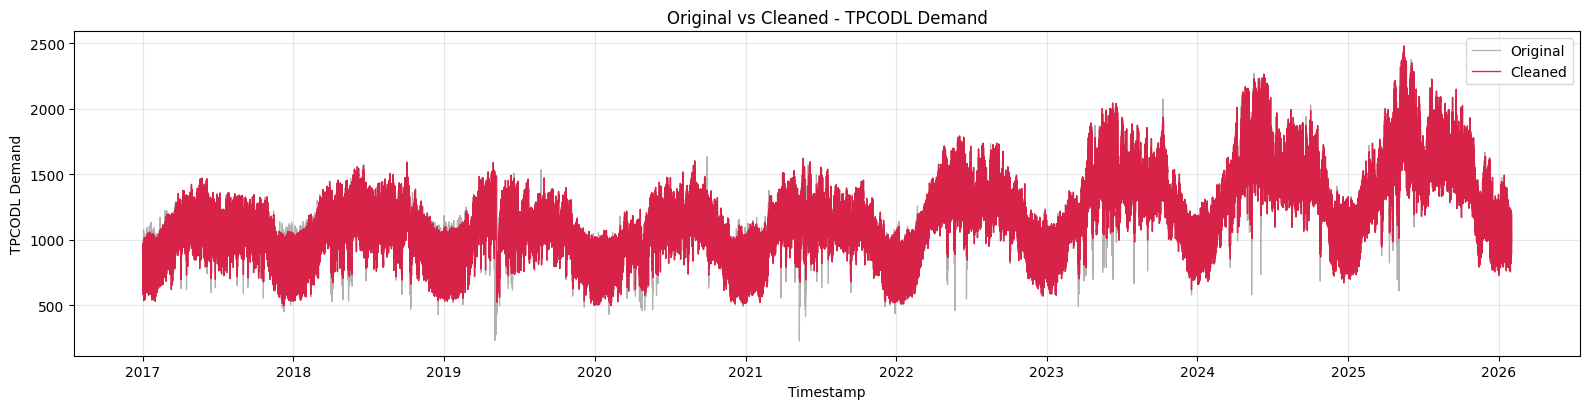

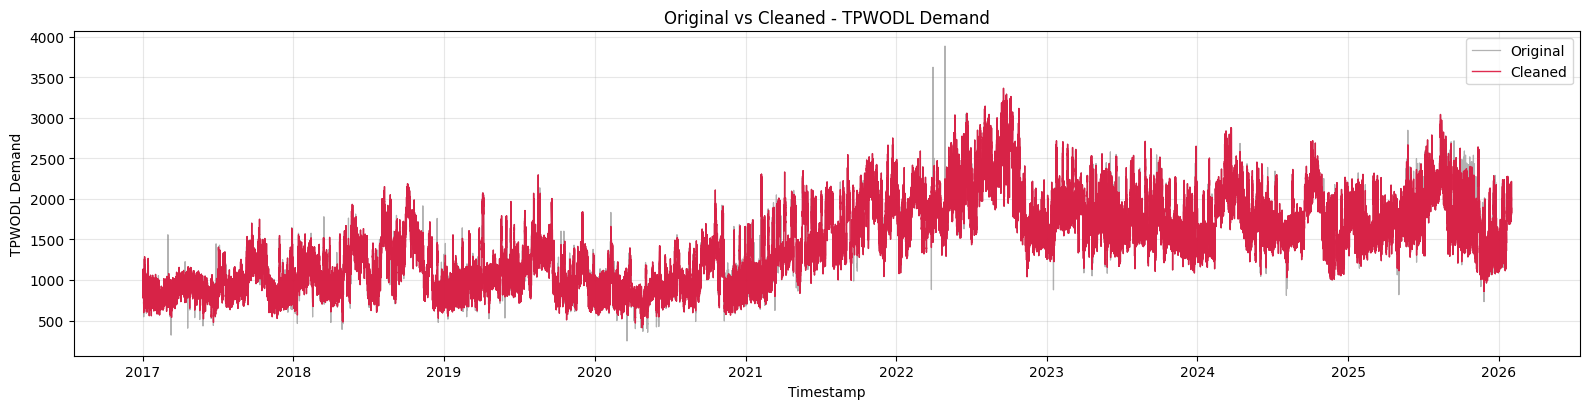

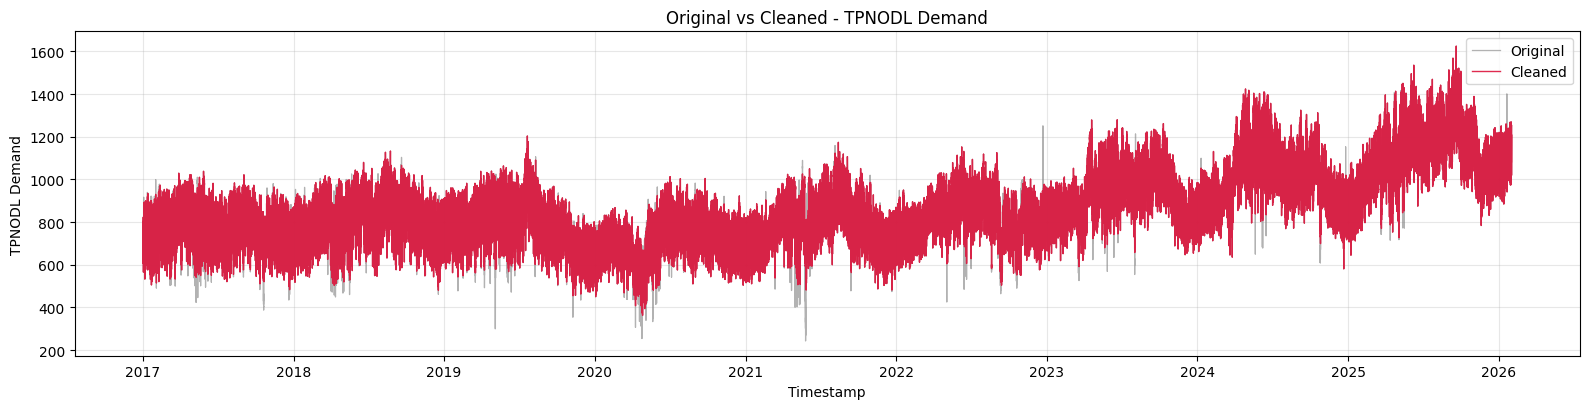

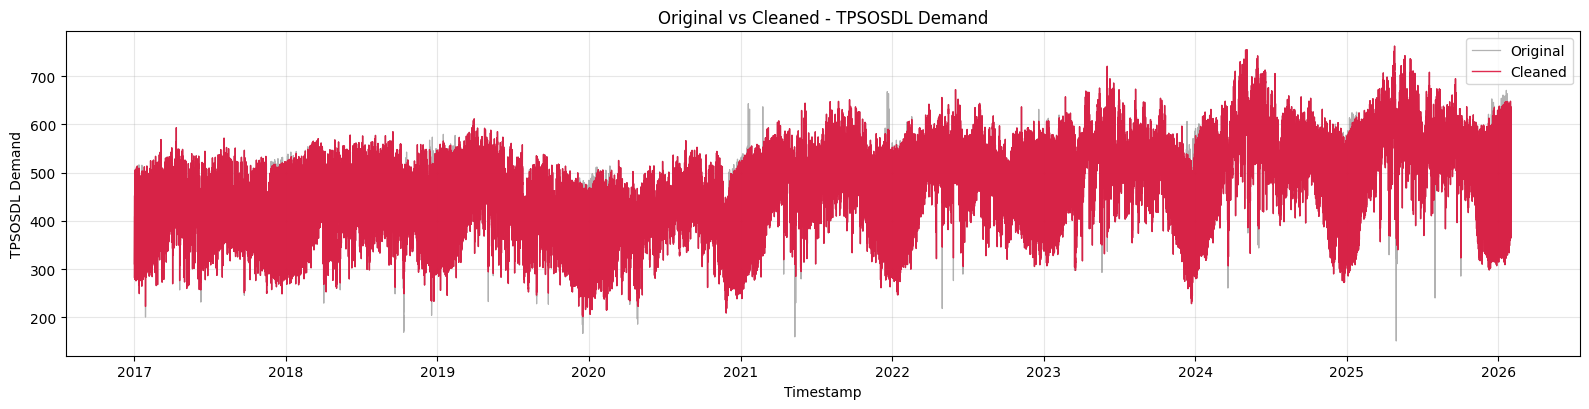

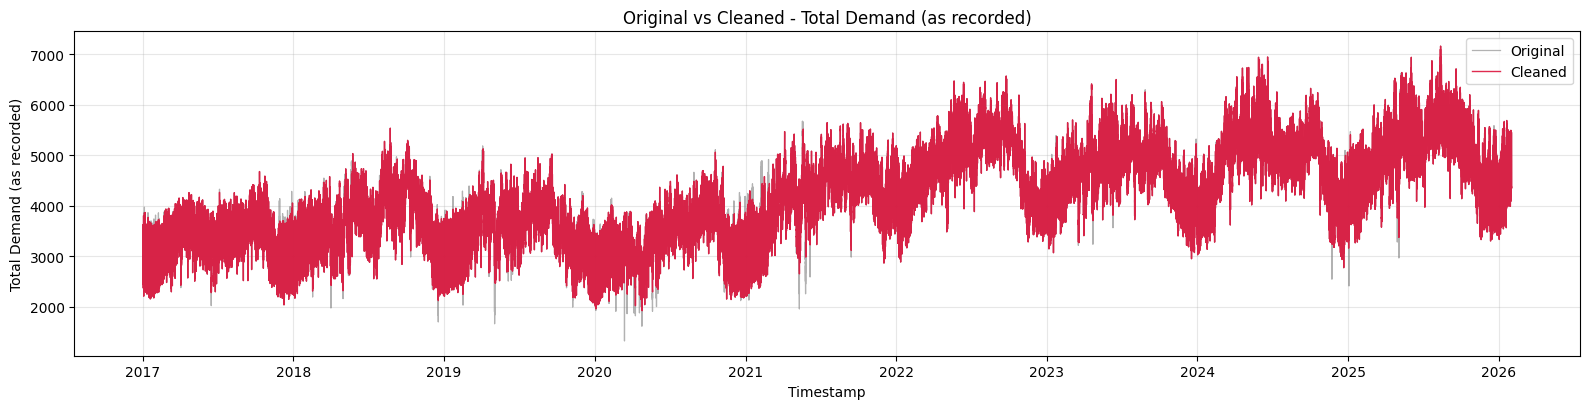

In [64]:
# -----------------------------
# FINAL CHECK: Full cleaned data visualization for each zone
# + Original vs Cleaned comparison
# -----------------------------
zone_columns = [c for c in cleaned_df.columns if c != "Timestamp"]

print("Zones plotted:", zone_columns)
print("Rows in original data:", len(df))
print("Rows in cleaned data:", len(cleaned_df))

# # 1) Cleaned full series (Matplotlib)
# for col in zone_columns:
#     plt.figure(figsize=(16, 3.8))
#     plt.plot(cleaned_df["Timestamp"], cleaned_df[col], color="navy", linewidth=0.8)
#     plt.title(f"Cleaned Full Series - {col}")
#     plt.xlabel("Timestamp")
#     plt.ylabel(col)
#     plt.grid(alpha=0.3)
#     plt.tight_layout()
#     plt.show()

# 2) Original vs Cleaned comparison (Matplotlib)
for col in zone_columns:
    plt.figure(figsize=(16, 4.2))
    plt.plot(df["Timestamp"], pd.to_numeric(df[col], errors="coerce"), color="gray", linewidth=0.9, alpha=0.6, label="Original")
    plt.plot(cleaned_df["Timestamp"], pd.to_numeric(cleaned_df[col], errors="coerce"), color="crimson", linewidth=1.0, alpha=0.9, label="Cleaned")
    plt.title(f"Original vs Cleaned - {col}")
    plt.xlabel("Timestamp")
    plt.ylabel(col)
    plt.legend(loc="upper right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# # 3) Interactive cleaned-only plots (Plotly)
# try:
#     import plotly.graph_objects as go

#     for col in zone_columns:
#         fig = go.Figure()
#         fig.add_trace(
#             go.Scatter(
#                 x=cleaned_df["Timestamp"],
#                 y=cleaned_df[col],
#                 mode="lines",
#                 name=f"Cleaned {col}",
#                 line=dict(color="#003f5c", width=1),
#             )
#         )
#         fig.update_layout(
#             title=f"Cleaned Full Series - {col} (Interactive)",
#             xaxis_title="Timestamp",
#             yaxis_title=col,
#             hovermode="x unified",
#             template="plotly_white",
#             height=460,
#         )
#         fig.show()
# except ImportError:
#     print("Plotly is not installed. Run: pip install plotly")



In [65]:
cleaned_df.to_csv("cleaned_demand_data.csv", index=False, date_format='%Y-%m-%d %H:%M:%S')